In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


ModuleNotFoundError: No module named 'tensorflow'

In [2]:
import os

# Set the path to your dataset
dataset_path = "C:/Users/user/Downloads/archive (31)"  # Full path to the archive folder with space

# Define the training and testing directories
train_dir = os.path.join(dataset_path, "training")  # Path to 'training' folder
test_dir = os.path.join(dataset_path, "testing")    # Path to 'testing' folder

# Define the categories
categories = ["glioma", "meningioma", "notumor", "pituitary"]  # Correct category names

# Print the paths for debugging
print(f"Train directory: {train_dir}")
print(f"Test directory: {test_dir}")

# Example of listing files in the 'glioma' folder under training
for category in categories:
    folder_path = os.path.join(train_dir, category)  # Path to each category inside 'training'
    
    # Check if the folder exists
    if os.path.exists(folder_path):
        images = os.listdir(folder_path)  # List of images in this category
        print(f"{category} has {len(images)} images in the training set.")
    else:
        print(f"Folder path does not exist: {folder_path}")


Train directory: C:/Users/user/Downloads/archive (31)\training
Test directory: C:/Users/user/Downloads/archive (31)\testing
glioma has 1321 images in the training set.
meningioma has 1339 images in the training set.
notumor has 1595 images in the training set.
pituitary has 1457 images in the training set.


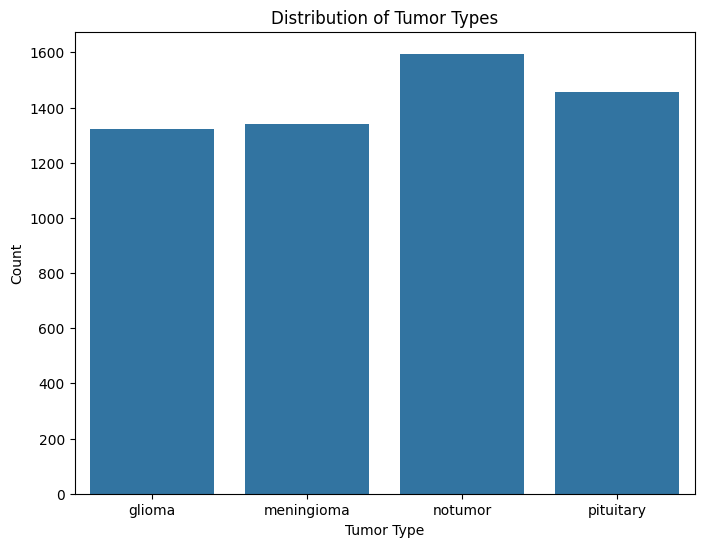

In [3]:
# Load and preprocess the dataset
train_data = []
for category in categories:
    folder_path = os.path.join(train_dir, category)
    images = os.listdir(folder_path)
    count = len(images)
    train_data.append(pd.DataFrame({"Image": images, "Category": [category] * count, "Count": [count] * count}))

train_df = pd.concat(train_data, ignore_index=True)

# Visualize the distribution of tumor types in the training dataset
plt.figure(figsize=(8, 6))
sns.barplot(data=train_df, x="Category", y="Count")
plt.title("Distribution of Tumor Types")
plt.xlabel("Tumor Type")
plt.ylabel("Count")
plt.show()


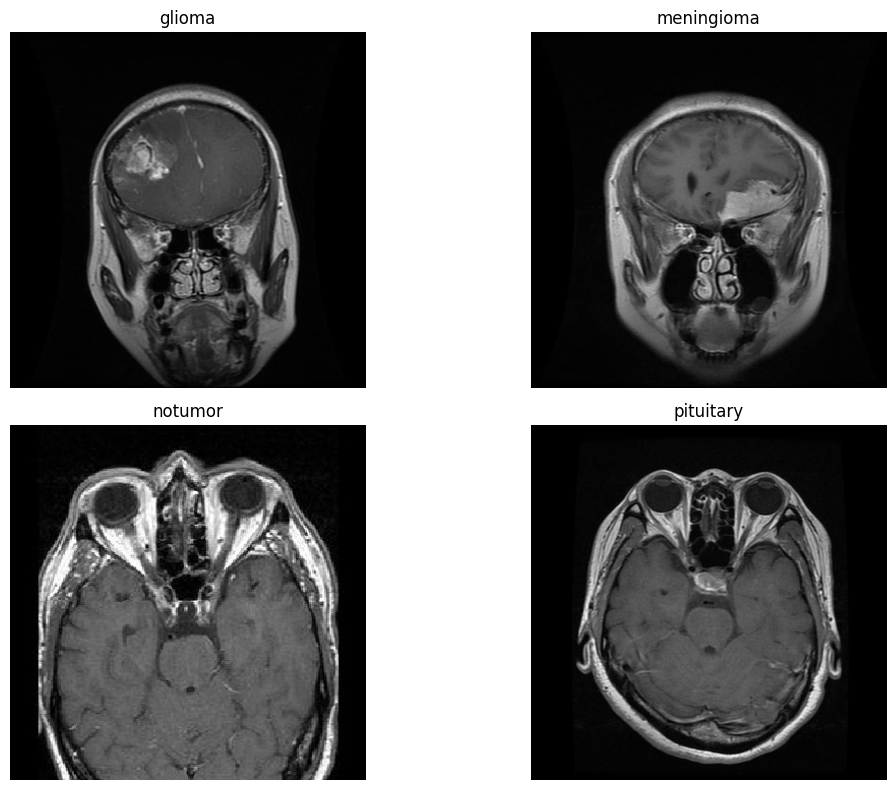

In [4]:
# Visualize sample images for each tumor type
plt.figure(figsize=(12, 8))
for i, category in enumerate(categories):
    folder_path = os.path.join(train_dir, category)
    image_path = os.path.join(folder_path, os.listdir(folder_path)[0])
    img = plt.imread(image_path)
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [5]:
# Set the image size
image_size = (150, 150)

# Set the batch size for training
batch_size = 32

# Set the number of epochs for training
epochs = 50

In [6]:
# Data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical"
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [7]:
# Define the model architecture
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(image_size[0], image_size[1], 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation="relu"),
    Dropout(0.5),
    Dense(len(categories), activation="softmax")
])

# Compile the model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


In [8]:
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=test_generator,
    validation_steps=test_generator.samples // batch_size
)

Epoch 1/50


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


178/178 ━━━━━━━━━━━━━━━━━━━━ 300s 2s/step - accuracy: 0.4573 - loss: 1.1421 - val_accuracy: 0.5664 - val_loss: 1.0766
Epoch 2/50
  1/178 ━━━━━━━━━━━━━━━━━━━━ 2:16 769ms/step - accuracy: 0.6250 - loss: 0.8628

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\contextlib.py:155: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6250 - loss: 0.8628 - val_accuracy: 0.3548 - val_loss: 1.4897
Epoch 3/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.7185 - loss: 0.7288 - val_accuracy: 0.6109 - val_loss: 1.0250
Epoch 4/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5938 - loss: 0.8275 - val_accuracy: 0.5806 - val_loss: 0.9314
Epoch 5/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.7405 - loss: 0.6621 - val_accuracy: 0.6844 - val_loss: 0.7504
Epoch 6/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7500 - loss: 0.6106 - val_accuracy: 0.9677 - val_loss: 0.2580
Epoch 7/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 131s 713ms/step - accuracy: 0.7721 - loss: 0.5780 - val_accuracy: 0.6859 - val_loss: 0.8551
Epoch 8/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8438 - loss: 0.4392 - val_accuracy: 0.9677 - val_loss: 0.3802
Epoch 9/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 166s 925ms/step - accuracy: 0.8053 - loss: 0.5197 - val_accuracy: 0.7

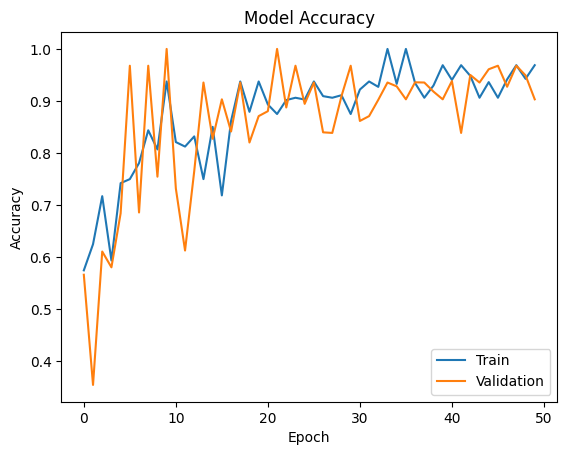

In [9]:
# Plot the training and validation accuracy over epochs
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

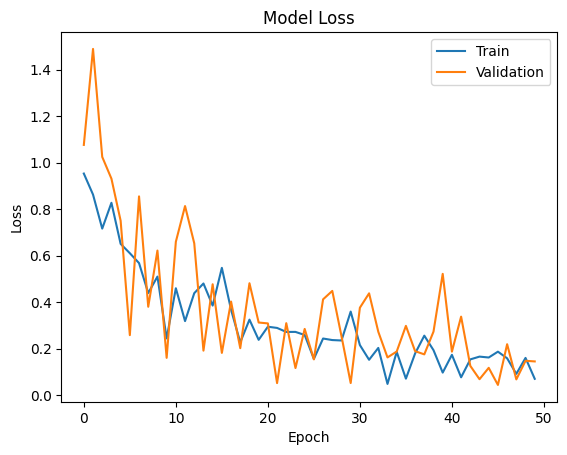

In [10]:
# Plot the training and validation loss over epochs
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [11]:
# Evaluate the model
loss, accuracy = model.evaluate(test_generator, steps=test_generator.samples // batch_size)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 216ms/step - accuracy: 0.9264 - loss: 0.1981
Test Loss: 0.15253980457782745
Test Accuracy: 0.948437511920929


41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step


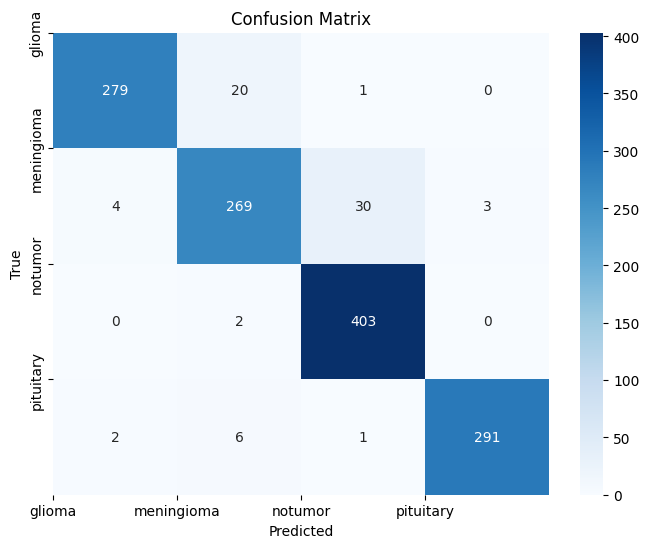

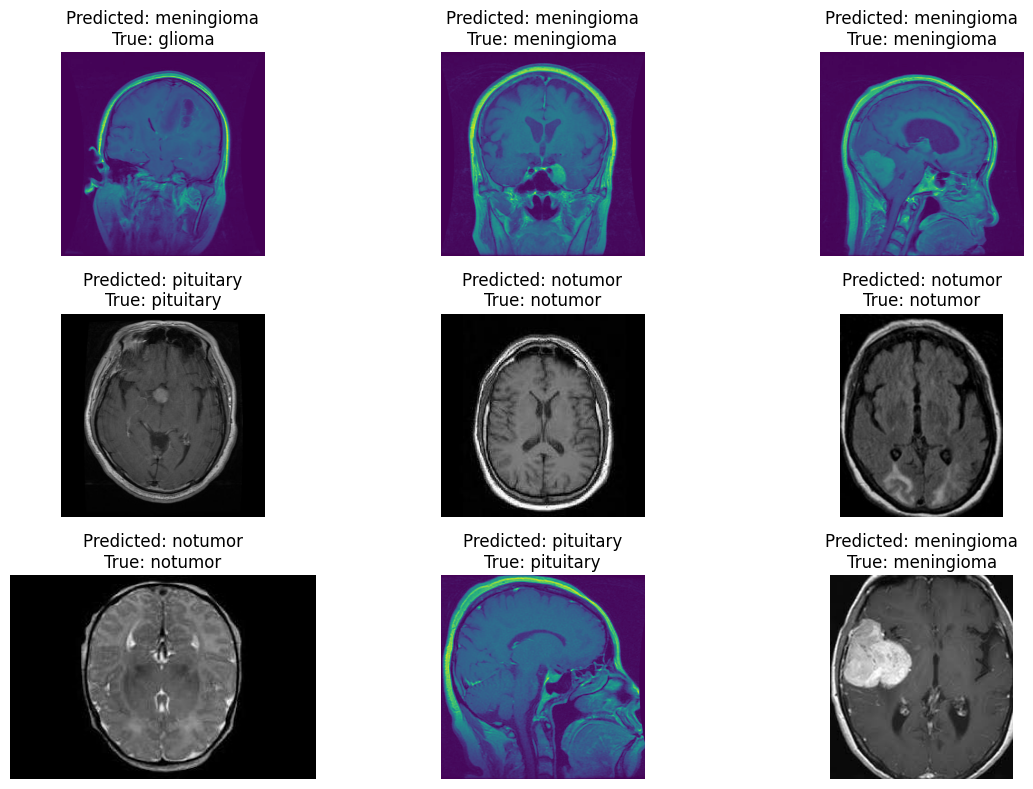

In [12]:
# Make predictions on the test dataset
predictions = model.predict(test_generator)
predicted_categories = np.argmax(predictions, axis=1)
true_categories = test_generator.classes

# Create a confusion matrix
confusion_matrix = tf.math.confusion_matrix(true_categories, predicted_categories)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(ticks=np.arange(len(categories)), labels=categories)
plt.yticks(ticks=np.arange(len(categories)), labels=categories)
plt.show()

# Plot sample images with their predicted and true labels
test_images = test_generator.filenames
sample_indices = np.random.choice(range(len(test_images)), size=9, replace=False)
sample_images = [test_images[i] for i in sample_indices]
sample_predictions = [categories[predicted_categories[i]] for i in sample_indices]
sample_true_labels = [categories[true_categories[i]] for i in sample_indices]

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    img = plt.imread(os.path.join(test_dir, sample_images[i]))
    plt.imshow(img)
    plt.title(f"Predicted: {sample_predictions[i]}\nTrue: {sample_true_labels[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


Class: glioma
Precision: 0.9789473684210527
Recall: 0.93
F1-Score: 0.9538461538461539

Class: meningioma
Precision: 0.9057239057239057
Recall: 0.8790849673202614
F1-Score: 0.8922056384742951

Class: notumor
Precision: 0.9264367816091954
Recall: 0.9950617283950617
F1-Score: 0.9595238095238094

Class: pituitary
Precision: 0.9897959183673469
Recall: 0.97
F1-Score: 0.9797979797979798



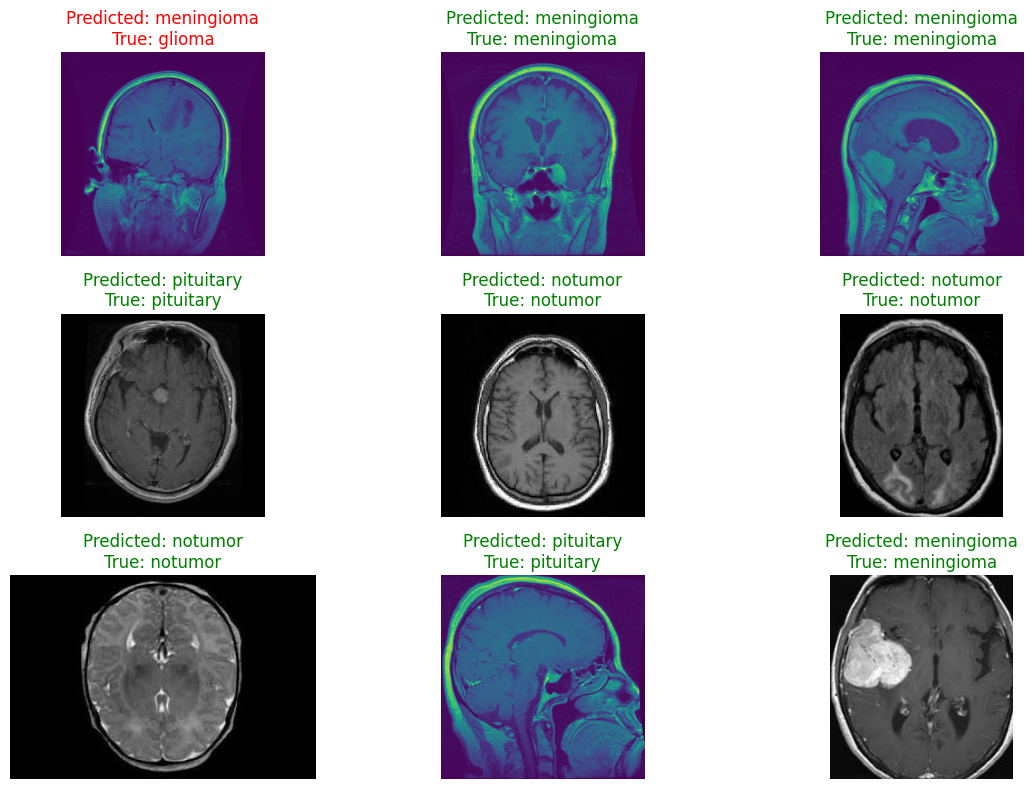

In [13]:
# Calculate precision, recall, and F1-score from the confusion matrix
precision = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=0)
recall = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=1)
f1_score = 2 * (precision * recall) / (precision + recall)

# Print precision, recall, and F1-score for each class
for i, category in enumerate(categories):
    print(f"Class: {category}")
    print(f"Precision: {precision[i]}")
    print(f"Recall: {recall[i]}")
    print(f"F1-Score: {f1_score[i]}")
    print()

# Analyze the sample images and their predictions
plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    img = plt.imread(os.path.join(test_dir, sample_images[i]))
    plt.imshow(img)
    if sample_predictions[i] == sample_true_labels[i]:
        plt.title(f"Predicted: {sample_predictions[i]}\nTrue: {sample_true_labels[i]}", color='green')
    else:
        plt.title(f"Predicted: {sample_predictions[i]}\nTrue: {sample_true_labels[i]}", color='red')
    plt.axis("off")
plt.tight_layout()
plt.show()

In [14]:
# Save the trained model
model.save("C:/Users/user/Downloads/archive (31)/brain_tumor_flask/brain_tumor_detection_model.keras")


In [15]:
from tensorflow.keras.preprocessing import image

def load_and_preprocess_image(img_path):
    # Load the image
    img = image.load_img(img_path, target_size=image_size)
    
    # Convert the image to a numpy array
    img_array = image.img_to_array(img)
    
    # Expand the dimensions to fit the model input
    img_array = np.expand_dims(img_array, axis=0)
    
    # Rescale the image (same as during training)
    img_array /= 255.0
    
    return img_array

def predict_image(model, img_path):
    # Preprocess the image
    img_array = load_and_preprocess_image(img_path)
    
    # Make a prediction
    predictions = model.predict(img_array)
    
    # Get the predicted category
    predicted_category = np.argmax(predictions, axis=1)
    
    return categories[predicted_category[0]]

# Test with a new image
image_path = r"C:\Users\user\Downloads\archive (31)\Testing\notumor\Te-no_0010.jpg"  # Use raw string
predicted_tumor_type = predict_image(model, image_path)
print(f"The predicted tumor type for the image is: {predicted_tumor_type}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
The predicted tumor type for the image is: notumor


In [16]:
from tensorflow.keras.models import load_model
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load the trained model
model_path = r"C:/Users/user/Downloads/archive (31)/brain_tumor_flask/brain_tumor_detection_model.keras"
model = load_model(model_path)

# Set the image size and batch size
image_size = (150, 150)
batch_size = 32

# Define the test data directory
test_data_dir = "C:/Users/user/Downloads/archive (31)/testing"  # Update this if the path changes

# Preprocess the test data
test_datagen = ImageDataGenerator(rescale=1./255)

# Define the test generator to load the images
test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",  # Use "binary" if you only have two classes without one-hot encoding
    shuffle=False
)

# Evaluate the model
# steps: total number of batches (test samples / batch_size), ensure all data is evaluated
steps = test_generator.samples // batch_size

loss, accuracy = model.evaluate(test_generator, steps=steps)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


Found 1311 images belonging to 4 classes.
 1/40 ━━━━━━━━━━━━━━━━━━━━ 26s 683ms/step - accuracy: 0.9375 - loss: 0.1679

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step - accuracy: 0.9264 - loss: 0.1981
Test Loss: 0.15253980457782745
Test Accuracy: 0.948437511920929


In [17]:
from tensorflow.keras.models import load_model
import numpy as np

# Load the trained model
model_path = "C:/Users/user/Downloads/archive (31)/brain_tumor_flask/brain_tumor_detection_model.keras"
model = load_model(model_path)

# Check the summary of the model
model.summary()

# Get the count of trainable and non-trainable parameters
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable_params = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print(f"Trainable parameters: {trainable_params}")
print(f"Non-trainable parameters: {non_trainable_params}")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,363,982 (39.54 MB)

 Trainable params: 3,454,660 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,909,322 (26.36 MB)

Trainable parameters: 3454660
Non-trainable parameters: 0.0


In [18]:
# Check the summary of your model
model.summary()

# Get the count of trainable and non-trainable parameters
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable_params = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print(f"Trainable parameters: {trainable_params}")
print(f"Non-trainable parameters: {non_trainable_params}")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,363,982 (39.54 MB)

 Trainable params: 3,454,660 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,909,322 (26.36 MB)

Trainable parameters: 3454660
Non-trainable parameters: 0.0
